##  GEREKLİ KÜTÜPHANELERİN İÇE AKTARILMASI

In [40]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd

## KLASÖRDEKİ DOSYALARI GÖRÜNTÜLEME

In [41]:
import os
print(os.listdir('../input/pima-indians-diabetes-database'))

['diabetes.csv']


## SÜTUNLARIN DAĞILIMINI GÖSTEREN GRAFİK FONKSİYONU

In [42]:
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    import numpy as np
    import matplotlib.pyplot as plt
    import math

    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    columnNames = list(df)
    
    # En önemli satır: TAMSAYI olması gerekiyor!
    nGraphRow = math.ceil((nCol + nGraphPerRow - 1) / nGraphPerRow)
    
    plt.figure(num=None, figsize=(6 * nGraphPerRow, 8 * nGraphRow), dpi=80, facecolor='w', edgecolor='k')
    
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if not np.issubdtype(columnDf.dtype, np.number):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation=90)
        plt.title(f'{columnNames[i]} (column {i})')
    
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    plt.show()


##  KORELASYON MATRİSİ GÖSTERME

In [43]:
def plotCorrelationMatrix(df, graphWidth):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Eğer dataframeName özelliği varsa başlığa eklenir
    filename = getattr(df, "dataframeName", "DataFrame")

    df = df.dropna(axis='columns')  # ✔️ doğru kullanım
    df = df[[col for col in df if df[col].nunique() > 1]]  # Tek tip verileri at
    
    if df.shape[1] < 2:
        print(f"Correlation matrix not plotted due to insufficient number of columns (less than 2) in {filename}.")
        return

    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(graphWidth, graphWidth))
    sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, 
                cmap='RdBu_r', annot=True, fmt=".2f", square=True)
    plt.title(f'Correlation Matrix for {filename}')
    plt.show()


## SCATTER MATRIX (Saçılım Grafikleri ve Yoğunluk)

In [44]:
def plotScatterMatrix(df, plotSize, textSize):
    import matplotlib.pyplot as plt
    from pandas.plotting import scatter_matrix

    df = df.select_dtypes(include=[np.number])  # Sadece sayısal sütunları al
    df = df.dropna(axis='columns')  # ✔️ Doğru argüman
    df = df[[col for col in df if df[col].nunique() > 1]]  # Tek tip sütunları çıkar
    columnNames = list(df)
    
    if len(columnNames) > 1:
        plt.figure()
        scatter_matrix(df, alpha=0.8, figsize=(plotSize, plotSize), diagonal='hist')
        plt.suptitle("Scatter Matrix")
        plt.show()
    else:
        print("Scatter matrix cannot be plotted with less than 2 numerical columns.")


##  VERİ SETİNİ OKUMA

In [45]:
nRowsRead = 1000 # specify 'None' if want to read whole file
df1 = pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')
df1.dataframeName = 'diabetes.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 768 rows and 9 columns


##  İLK 5 SATIRI GÖSTERME

In [46]:
df1.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## GÖRSELLEŞTİRMELERİN ÇAĞIRILMASI

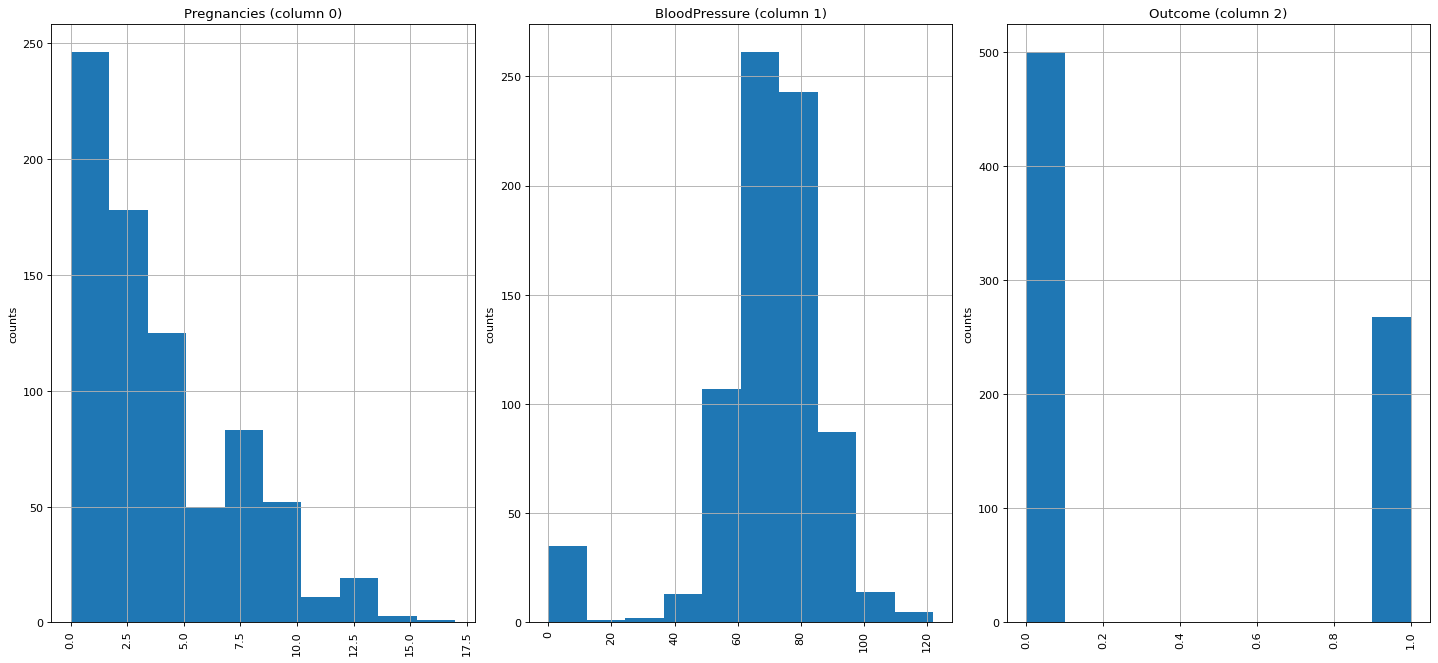

In [47]:
plotPerColumnDistribution(df1, 10, 5)


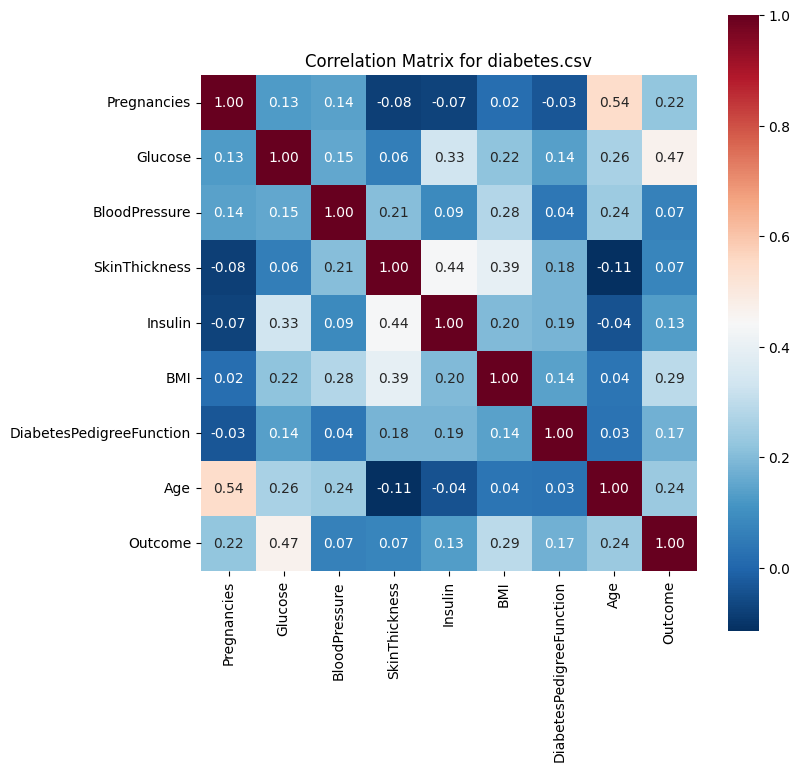

In [48]:
plotCorrelationMatrix(df1, 8)

<Figure size 640x480 with 0 Axes>

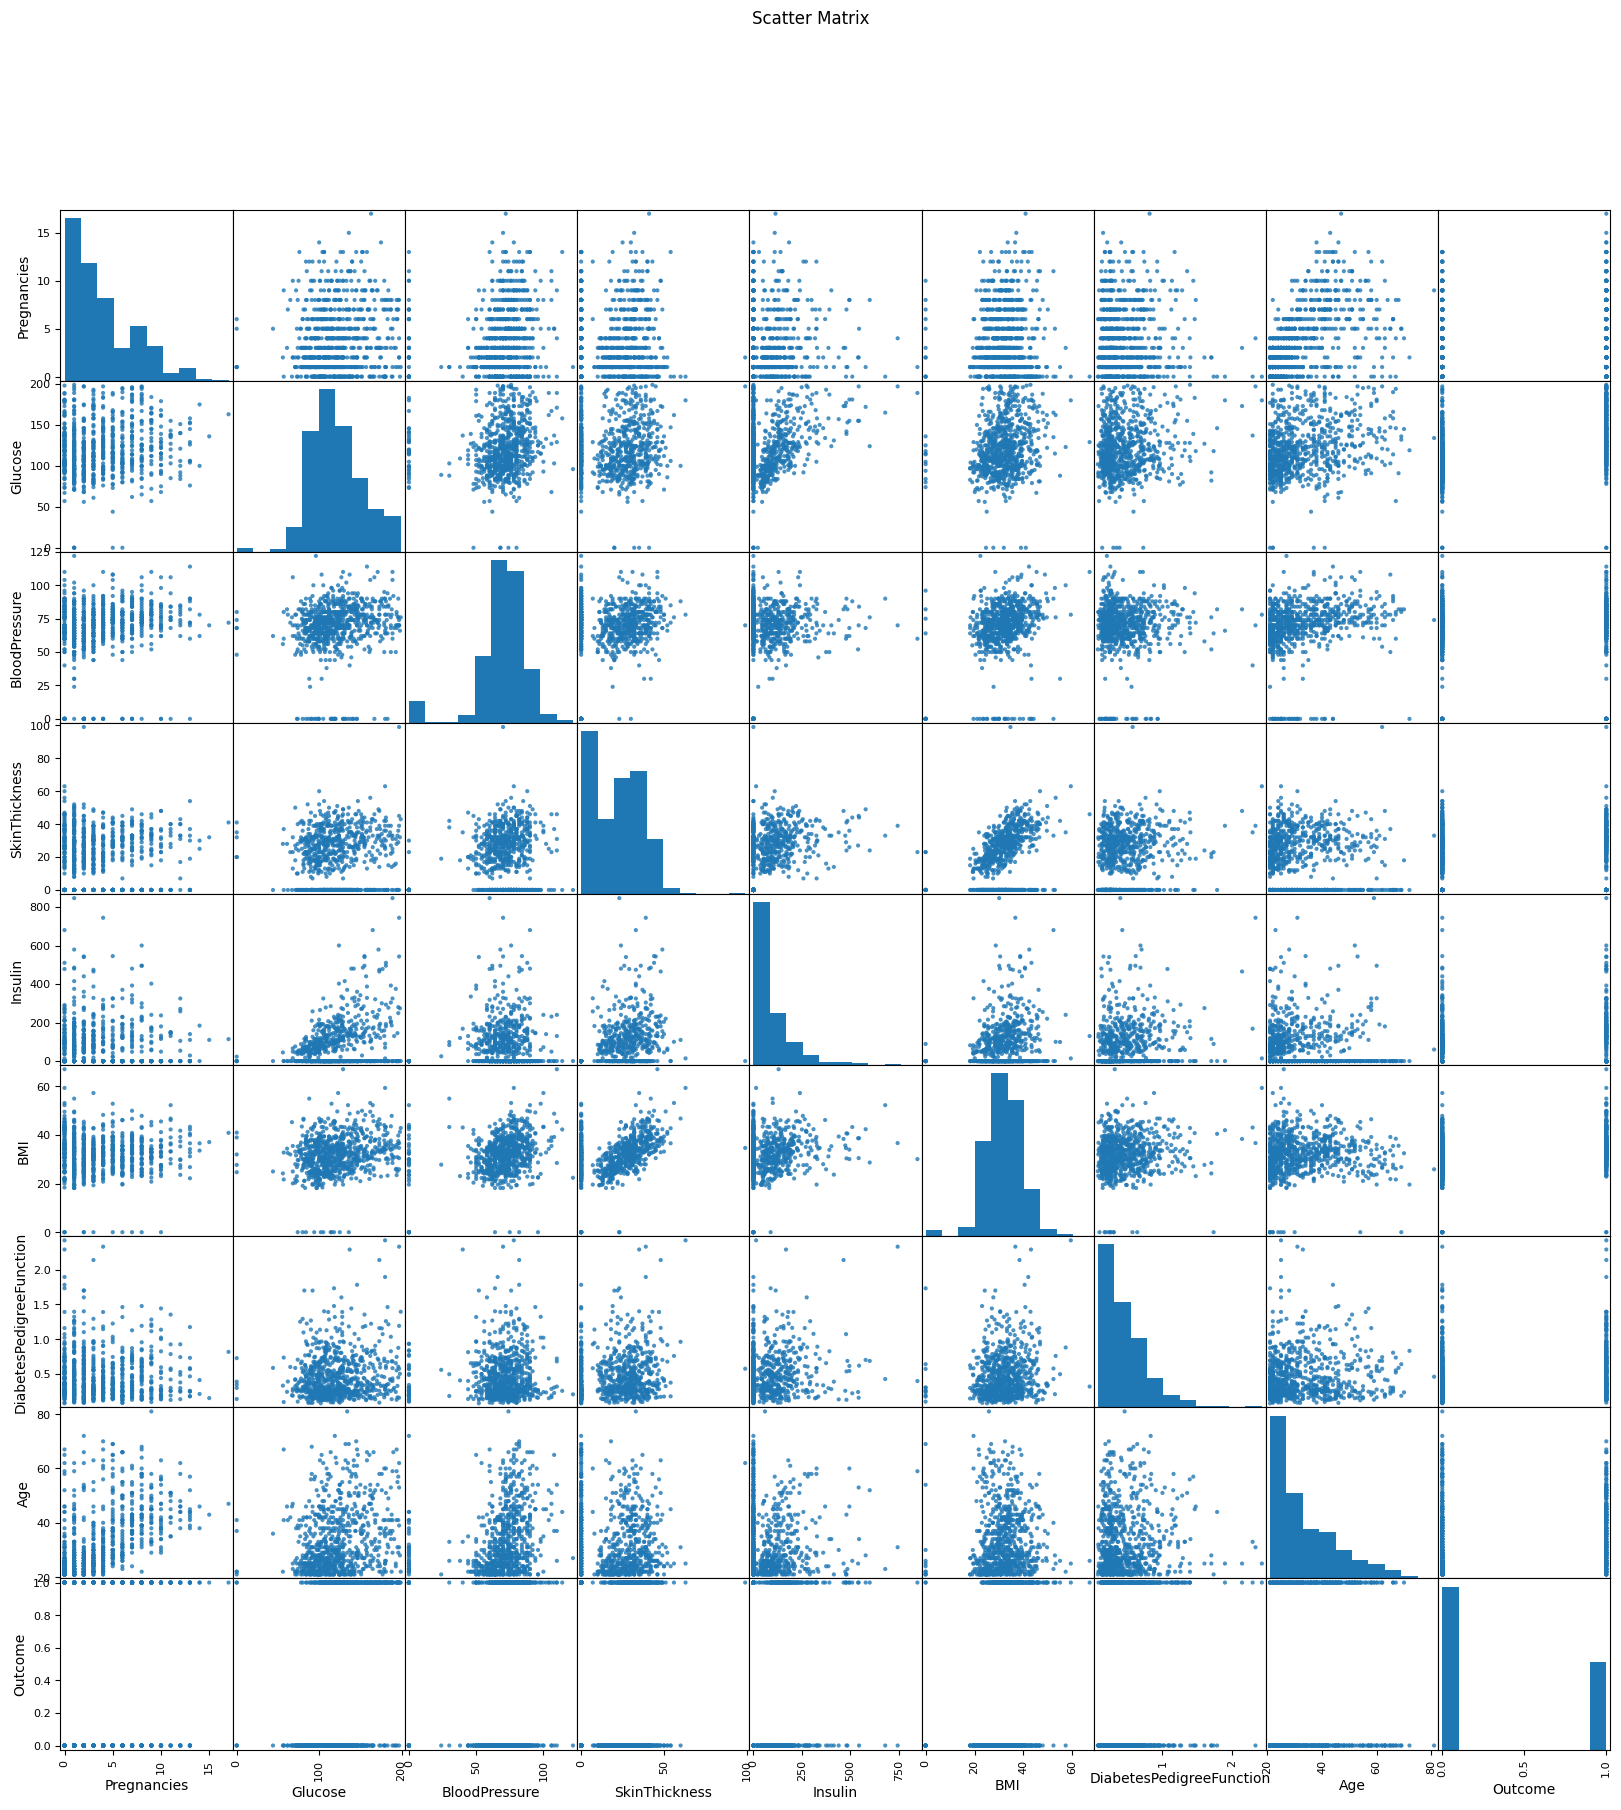

In [49]:
plotScatterMatrix(df1, 20, 10)
